# CNN Cancel Detection

## 1. Introduction

This project is developed for the Kaggle Challenge [Histopathologic Cancer Detection](https://www.kaggle.com/competitions/histopathologic-cancer-detection/data) using Convolutional Neural Network (CNN). The dataset comes from a modified version of the PatchCamelyon (PCam) benchmark and includes over 200,000 RGB pathology images in TIFF format, all with the same size (96x96). The goal is to predict the label of each test image by determining whether the central 32×32 pixel region of the patch contains at least one pixel of tumor tissue.

The project contains three main steps:
- Exploratory Data Analysis (EDA): examining and understanding the dataset.
- Model Architecture: building and training a Convolutional Neural Network (CNN).
- Results and Analysis: testing the model, tuning hyperparameters, and improving the architecture.

## 2. Exploratory Data Analysis (EDA)

In this step, I loaded and inspected the dataset and implemented a preprocessing method to prepare the images for training.

First, I checked how many images were included in the training and test datasets. Then, I ensured that the training data contained no null values or duplicate entries. Next, I examined the distribution of normal and cancer images in the training set. As shown in the diagram below, 59.50% of the images are normal and 40.50% are cancer, which indicates that the dataset is slightly imbalanced. After that, I inspected a random image from the training set to check its dimensions and color mode.

In [64]:
import os
from glob import glob
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

In [65]:
train_images = pd.DataFrame({'path': glob(os.path.join('./data/train', '*.tif'))})
test_images = pd.DataFrame({'path': glob(os.path.join('./data/test', '*.tif'))})
print("Train images:", len(train_images))
print("Test images:", len(test_images))

Train images: 220025
Test images: 57458


In [66]:
train = pd.read_csv('./data/train_labels.csv')
train.info()

print(train.head())
print("Duplicated train images:", train['id'].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220025 entries, 0 to 220024
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      220025 non-null  object
 1   label   220025 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.4+ MB
                                         id  label
0  f38a6374c348f90b587e046aac6079959adf3835      0
1  c18f2d887b7ae4f6742ee445113fa1aef383ed77      1
2  755db6279dae599ebb4d39a9123cce439965282d      0
3  bc3f0c64fb968ff4a8bd33af6971ecae77c75e08      0
4  068aba587a4950175d04c680d38943fd488d6a9d      0
Duplicated train images: 0


Label distribution:
0: 130908 (59.50%)
1: 89117 (40.50%)


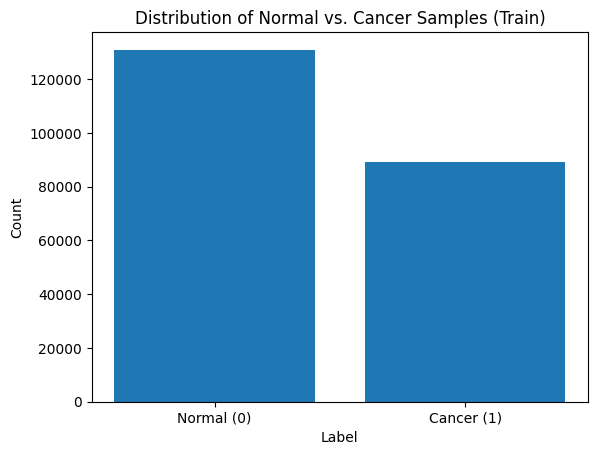

In [67]:
import matplotlib.pyplot as plt

label_counts = train['label'].value_counts()
label_percent = train['label'].value_counts(normalize=True) * 100

print("Label distribution:")
for label, count, pct in zip(label_counts.index, label_counts.values, label_percent.values):
    print(f"{label}: {count} ({pct:.2f}%)")

plt.bar(label_counts.index, label_counts.values, tick_label=["Normal (0)", "Cancer (1)"])
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Normal vs. Cancer Samples (Train)")
plt.show()

In [68]:
with Image.open(os.path.join('./data/train', f"{train.sample(1).iloc[0]['id']}.tif")) as img:
    print("Image size (width x height):", img.size)
    print("Image mode (channels):", img.mode)

Image size (width x height): (96, 96)
Image mode (channels): RGB


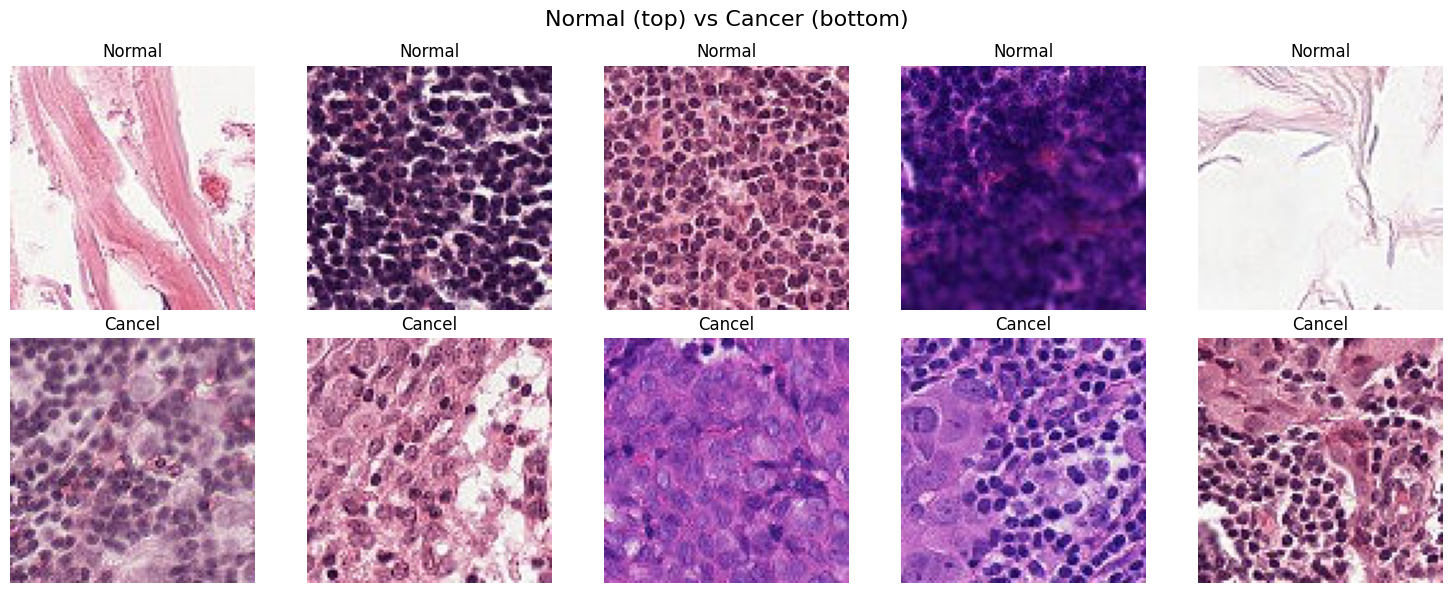

In [69]:
normal_samples = train[train['label'] == 0].sample(5, random_state=42)
cancer_samples = train[train['label'] == 1].sample(5, random_state=42)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, (idx, row) in enumerate(normal_samples.iterrows()):
    img_path = os.path.join('./data/train', f"{row['id']}.tif")
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title("Normal")
    axes[0, i].axis("off")

for i, (idx, row) in enumerate(cancer_samples.iterrows()):
    img_path = os.path.join('./data/train', f"{row['id']}.tif")
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title("Cancel")
    axes[1, i].axis("off")

plt.suptitle("Normal (top) vs Cancer (bottom)", fontsize=16)
plt.tight_layout()
plt.show()

The following method is used to load a TIFF image, crop it to the central 32×32 region (which is used for prediction according to the challenge), normalize the pixel values to the range [0, 1], and return the processed image together with its label for training.

In [72]:
def preprocess_image(img_path, label, crop_size=32):
    def load_tiff(path):
        path_str = path.numpy().decode('utf-8')
        img = Image.open(path_str)
        
        # crop the center
        w, h = img.size
        left = (w - crop_size) // 2
        top = (h - crop_size) // 2
        right = left + crop_size
        bottom = top + crop_size
        img = img.crop((left, top, right, bottom))
        
        img = np.array(img, dtype=np.float32)
        return img
        
    img = tf.py_function(load_tiff, [img_path], tf.float32)
    img.set_shape([crop_size, crop_size, 3])
    img = img / 255.0
    label = tf.cast(label, tf.float32)
    return img, label

## 3. Model Architecture

Since the relevant image region is very small (32x32), I started with a simple baseline model consisting of three convolutional blocks. Each block contains a `Conv2D` layer with ReLU activation to extract hierarchical spatial features and introduce non-linearity, followed by a pooling layer to reduce the spatial dimensions of the feature maps. In the last block, `GlobalAveragePooling2D` is applied to aggregate each feature map into a single value, which helps prevent overfitting. After that, I added a dense layer with dropout for classification and regularization, and finally an output layer with a sigmoid activation function.

In [73]:
train['path'] = train['id'].apply(lambda x: f"./data/train/{x}.tif")
train_df, val_df = train_test_split(train, test_size=0.2, stratify=train['label'], random_state=42)

def df_to_dataset(df, shuffle=True, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices((df['path'].values, df['label'].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def simple_cnn(input_shape=(32, 32, 3), learning_rate=1e-3):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', 'auc']
    )
    return model

In [74]:
model = simple_cnn()
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
BATCH_SIZE = 32
EPOCHS = 15

train_dataset = df_to_dataset(train_df, batch_size=BATCH_SIZE)
val_dataset = df_to_dataset(val_df, shuffle=False, batch_size=BATCH_SIZE)

In [76]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/15
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 403s 73ms/step - accuracy: 0.7759 - auc: 0.8367 - loss: 0.4878 - val_accuracy: 0.7942 - val_auc: 0.8643 - val_loss: 0.4540
Epoch 2/15
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 383s 69ms/step - accuracy: 0.8055 - auc: 0.8700 - loss: 0.4391 - val_accuracy: 0.8130 - val_auc: 0.8850 - val_loss: 0.4213
Epoch 3/15
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 360s 65ms/step - accuracy: 0.8157 - auc: 0.8825 - loss: 0.4197 - val_accuracy: 0.8145 - val_auc: 0.8859 - val_loss: 0.4156
Epoch 4/15
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 360s 65ms/step - accuracy: 0.8216 - auc: 0.8892 - loss: 0.4077 - val_accuracy: 0.8220 - val_auc: 0.8949 - val_loss: 0.3988
Epoch 5/15
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 369s 67ms/step - accuracy: 0.8257 - auc: 0.8947 - loss: 0.3984 - val_accuracy: 0.8241 - val_auc: 0.9040 - val_loss: 0.3994
Epoch 6/15
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 398s 72ms/step - accuracy: 0.8314 - auc: 0.8992 - loss: 0.3895 - val_accuracy: 0.8320 - val_auc: 0.9040 - val_loss: 0.3819
Epoch 7/15

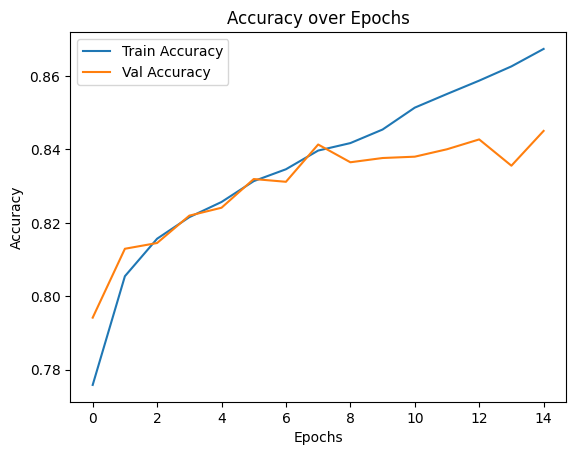

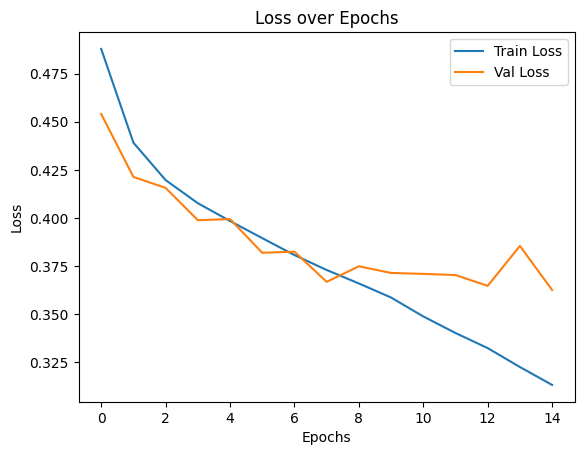

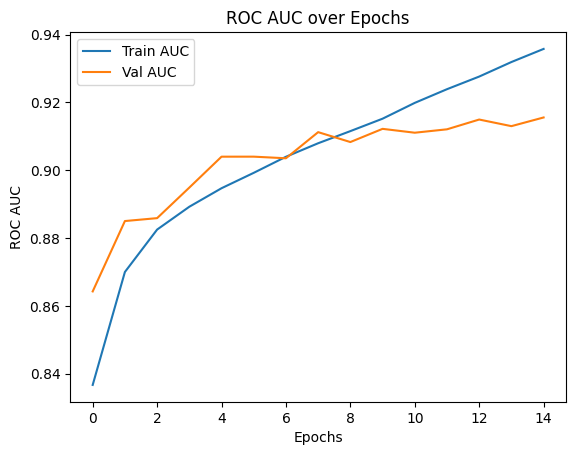

In [77]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# Plot Roc
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.xlabel('Epochs')
plt.ylabel('ROC AUC')
plt.legend()
plt.title('ROC AUC over Epochs')
plt.show()

As shown in the plots, with a learning rate of 1e-3, the validation accuracy stopped improving around epoch 13, indicating that the learning rate was probably too high and the model converged quickly. In the next step, I will fine-tune some hyperparameters.

## 4. Results and Analysis

### 4.1 Hyperparameter tuning

In [78]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# start with a smaller LR 1e-4
model = simple_cnn(learning_rate=1e-4)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=2, # stop if no improvement for 2 epochs
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5, # stop if no improvement for 5 epochs
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/50
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 400s 72ms/step - accuracy: 0.7521 - auc: 0.8116 - loss: 0.5203 - val_accuracy: 0.7708 - val_auc: 0.8398 - val_loss: 0.4904 - learning_rate: 1.0000e-04
Epoch 2/50
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 417s 76ms/step - accuracy: 0.7756 - auc: 0.8365 - loss: 0.4880 - val_accuracy: 0.7793 - val_auc: 0.8515 - val_loss: 0.4755 - learning_rate: 1.0000e-04
Epoch 3/50
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 413s 75ms/step - accuracy: 0.7882 - auc: 0.8507 - loss: 0.4681 - val_accuracy: 0.7980 - val_auc: 0.8657 - val_loss: 0.4472 - learning_rate: 1.0000e-04
Epoch 4/50
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 397s 72ms/step - accuracy: 0.8003 - auc: 0.8639 - loss: 0.4480 - val_accuracy: 0.7900 - val_auc: 0.8737 - val_loss: 0.4536 - learning_rate: 1.0000e-04
Epoch 5/50
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 406s 74ms/step - accuracy: 0.8072 - auc: 0.8716 - loss: 0.4363 - val_accuracy: 0.8127 - val_auc: 0.8834 - val_loss: 0.4257 - learning_rate: 1.0000e-04
Epoch 6/50
5501/5501 ━━━━━━━━━━━━━━

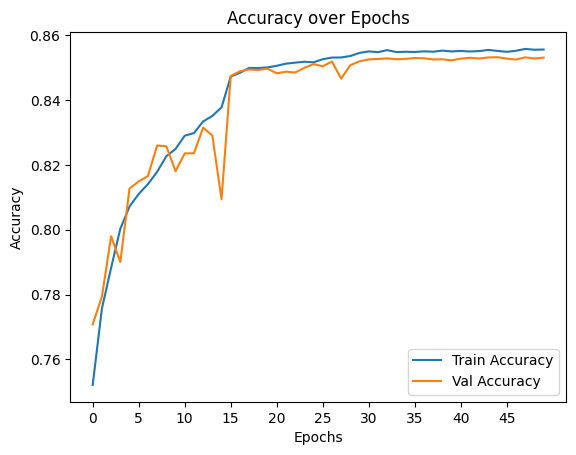

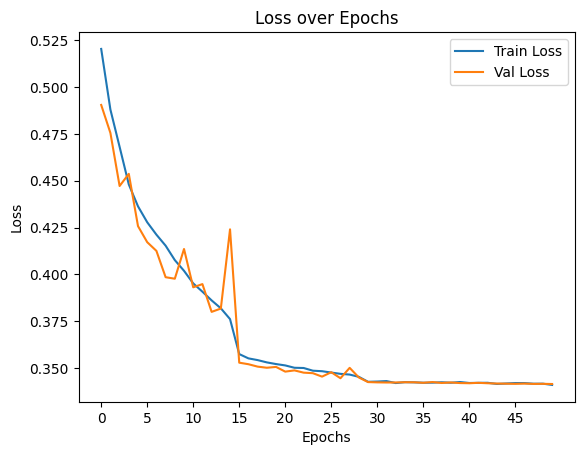

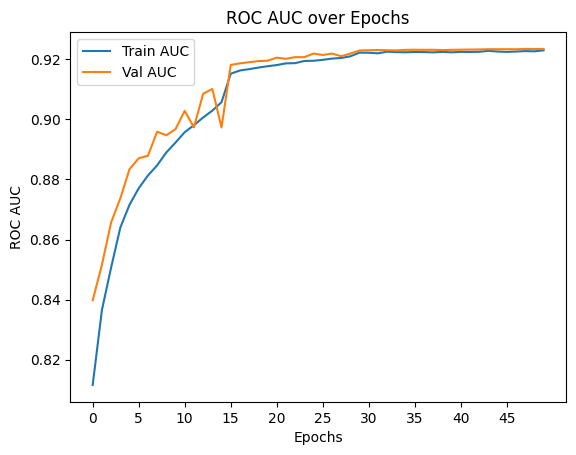

In [84]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.xticks(np.arange(0, 50, 5))
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.xticks(np.arange(0, 50, 5))
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# Plot Roc
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.xlabel('Epochs')
plt.xticks(np.arange(0, 50, 5))
plt.ylabel('ROC AUC')
plt.legend()
plt.title('ROC AUC over Epochs')
plt.show()

From the new plots, we can see that the overall accuracy increased with a smaller learning rate. The model converged more slowly after around 15 epochs and had not stopped even at 50 epochs, which suggests that a lower learning rate helps, but further improvements in the model architecture are needed to achieve better accuracy.

### 4.2 Other architectures

My baseline model has the following limitations:
- Limited depth
- No batch normalization
- Only one dropout layer
- No L2 regularization

So I modified the model architecture with several optimizations to see if the performance could be improved.

In [90]:
def improved_simple_cnn(input_shape=(32, 32, 3), learning_rate=1e-4):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv2D(64, (5, 5), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.GlobalAveragePooling2D(),
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', 'auc']
    )
    return model

model = improved_simple_cnn()
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           51

 Total params: 594,497 (2.27 MB)

 Trainable params: 592,961 (2.26 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [91]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_auc',
    mode='max',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=8,
    restore_best_weights=True,
    min_delta=0.001
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/25
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 1597s 289ms/step - accuracy: 0.7801 - auc: 0.8421 - loss: 0.4911 - val_accuracy: 0.7996 - val_auc: 0.8860 - val_loss: 0.4358 - learning_rate: 1.0000e-04
Epoch 2/25
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 1584s 288ms/step - accuracy: 0.8104 - auc: 0.8764 - loss: 0.4306 - val_accuracy: 0.8220 - val_auc: 0.8979 - val_loss: 0.3984 - learning_rate: 1.0000e-04
Epoch 3/25
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 1583s 288ms/step - accuracy: 0.8274 - auc: 0.8945 - loss: 0.3972 - val_accuracy: 0.7420 - val_auc: 0.8680 - val_loss: 0.6284 - learning_rate: 1.0000e-04
Epoch 4/25
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 1578s 287ms/step - accuracy: 0.8360 - auc: 0.9037 - loss: 0.3802 - val_accuracy: 0.8182 - val_auc: 0.8873 - val_loss: 0.4104 - learning_rate: 1.0000e-04
Epoch 5/25
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 1597s 290ms/step - accuracy: 0.8408 - auc: 0.9087 - loss: 0.3708 - val_accuracy: 0.8205 - val_auc: 0.8917 - val_loss: 0.4281 - learning_rate: 1.0000e-04
Epoch 6/25
5501/5501 ━━━━

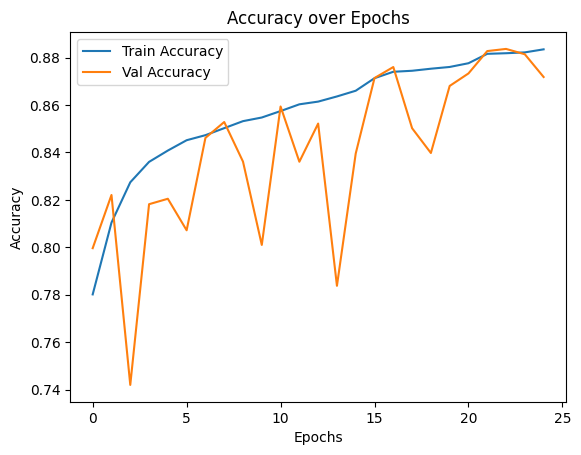

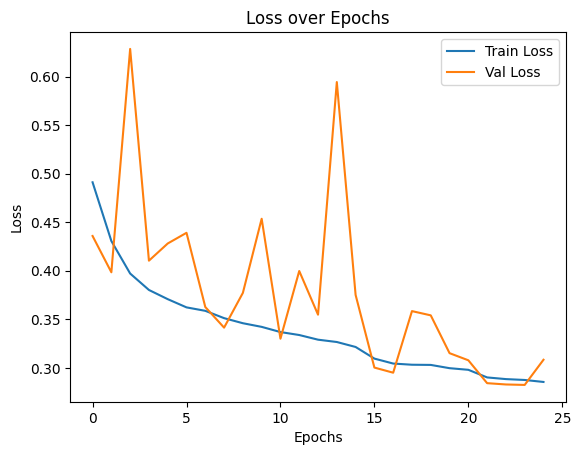

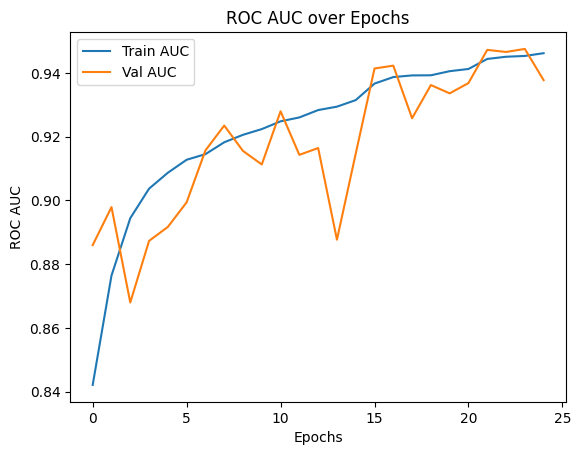

In [93]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# Plot Roc
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.xlabel('Epochs')
plt.ylabel('ROC AUC')
plt.legend()
plt.title('ROC AUC over Epochs')
plt.show()

1376/1376 ━━━━━━━━━━━━━━━━━━━━ 106s 77ms/step


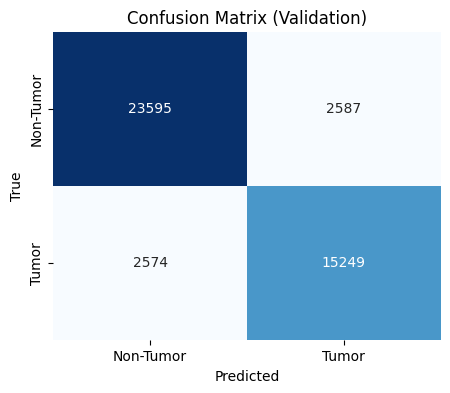

In [95]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = val_df['label'].values
y_pred_probs = model.predict(val_dataset)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Non-Tumor", "Tumor"],
            yticklabels=["Non-Tumor", "Tumor"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation)")
plt.show()

Due to my limited hardware and time, I trained the new model for only 25 epochs. Still, the results show an improvement on the validation dataset in both accuracy (from 0.85 to 0.88) and AUC (from 0.92 to 0.94) at epoch 25 compared to the baseline model. 

The following adjustments in the architecture contributed to this improvement:
- Using a 5x5 kernel size in the first layer to capture broader patterns, followed by 3x3 kernels to refine details.
- Increasing the number of filters per layer to provide more feature capacity.
- Adding a larger dense layer for better feature combination.

At the same time, the use of BatchNorm and the change in learning rate caused the validation curve to fluctuate more.

The main drawbacks of this architecture are higher computational cost caused by the increased number of parameters and the longer training time per epoch.

### 4.3 Predict test data

In [99]:
def preprocess_test_image(img_path, crop_size=32):
    def load_tiff(path):
        path_str = path.numpy().decode('utf-8')
        img = Image.open(path_str)

        w, h = img.size
        left = (w - crop_size) // 2
        top = (h - crop_size) // 2
        right = left + crop_size
        bottom = top + crop_size
        img = img.crop((left, top, right, bottom))
        
        img = np.array(img, dtype=np.float32)
        return img
        
    img = tf.py_function(load_tiff, [img_path], tf.float32)
    img.set_shape([crop_size, crop_size, 3])
    img = img / 255.0
    return img

test_paths = test_images['path'].values
test_ds = tf.data.Dataset.from_tensor_slices(test_paths)
test_ds = test_ds.map(preprocess_test_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(128).prefetch(tf.data.AUTOTUNE)

pred_probs = model.predict(test_ds, verbose=1).ravel()
pred_labels = (pred_probs >= 0.5).astype(int)
    
submission_df = pd.DataFrame({'id': [os.path.splitext(os.path.basename(p))[0] for p in test_paths], 'label': pred_labels})
submission_df.to_csv('submission.csv', index=False)

449/449 ━━━━━━━━━━━━━━━━━━━━ 138s 306ms/step


The submitted test data received a private score of 0.8018 (public score was 0.8161). Late submissions do not appear on the public leaderboard.

## 5. Conclusion

From the experiments, I found that a 3-block CNN model works well as a simple baseline for training on small images such as 32×32 patches. I also noticed that a large learning rate (1e-3) can cause the model to converge too quickly, which can limit performance. Using a learning rate schedule together with early stopping proved helpful in finding a more optimal balance between learning rate and number of epochs.

In terms of architecture, adjustments to kernel size, number of filters, dropout layers, and dense layers also had a noticeable impact on performance and can be tuned further for optimization.

For future work, it would be useful to try a larger batch size (e.g. 64 instead of 32), add data augmentation and increase the number of training epochs (e.g. 40 instead of 25) with adjusted patience. For larger images, it would also make sense to add more convolutional blocks to capture more complex patterns.

This notebook can be found in the [GitHub repo](https://github.com/YuKitAs/cnn-cancer-detection).

## References

* Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
* OpenAI. (2025). ChatGPT (GPT-5) [Large language model]. (Only used for phrasing suggestions and idea refinement; all experiments, coding and results were implemented and validated independently.)